In [9]:
import pfhedge
print(pfhedge.__version__)
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import ReLU
import scipy.stats as stats
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d
import matplotlib as mpl
from scipy.interpolate import RegularGridInterpolator

pd.set_option('display.max_columns',6)
pd.set_option('display.max_rows',6)

import matplotlib
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']  # 用于正常显示中文
plt.rcParams['axes.unicode_minus'] = False  # 用于正常显示负号

from pfhedge.instruments import BaseInstrument, EuropeanOption
from pfhedge.nn import BlackScholes, EntropicRiskMeasure, ExpectedShortfall, Hedger, MultiLayerPerceptron
from pfhedge.stochastic.local_volatility import generate_local_volatility_process
from pfhedge.instruments.primary.brownian import BrownianStock

0.23.0


In [10]:
class LocalVolatilityStock(BaseInstrument):
    """支持局部波动率的自定义股票类"""
    def __init__(self, cost: float = 0.0, dt: float = 1/250, sigma_fn=None):
        super().__init__()
        self.cost = cost
        self.dt = dt
        self.sigma_fn = sigma_fn
        # 直接作为属性存储，不使用 register_buffer
        self._spot = None
        self._volatility = None
        self._log_spot = None
        
    def to(self, device=None, dtype=None):
        """实现设备转移方法"""
        # 如果有数据，转移到指定设备
        if self._spot is not None:
            self._spot = self._spot.to(device=device, dtype=dtype)
        if self._volatility is not None:
            self._volatility = self._volatility.to(device=device, dtype=dtype)
        if self._log_spot is not None:
            self._log_spot = self._log_spot.to(device=device, dtype=dtype)
        return self
        
    @property
    def spot(self) -> torch.Tensor:
        """返回股价路径"""
        if self._spot is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._spot
    
    @property
    def log_spot(self) -> torch.Tensor:
        """返回对数股价路径"""
        if self._log_spot is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._log_spot
        
    def is_listed(self, time: float) -> bool:
        """检查股票在给定时间是否上市"""
        return True
        
    def simulate(self, n_paths: int, time_horizon: Optional[float] = None, 
                 init_state: Optional[Tuple[float, ...]] = None):
        """模拟股价路径"""
        if time_horizon is None:
            time_horizon = 30 * self.dt
        
        n_steps = int(time_horizon / self.dt)
        
        # 使用局部波动率模型生成路径
        spot, volatility = generate_local_volatility_process(
            n_paths, n_steps, self.sigma_fn, init_state, self.dt
        )
        
        # 直接存储为属性
        self._spot = spot
        self._volatility = volatility
        self._log_spot = spot.log()
        
        return self

    @property
    def volatility(self):
        """返回波动率路径"""
        if self._volatility is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._volatility

    @property
    def sigma(self):
        """返回波动率（兼容性）"""
        return self.volatility

def create_lv_hedger(loss, derivative, features, n_epochs, n_paths, init_spot, sigma_fn):
    """创建并训练使用局部波动率数据的对冲器"""
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    
    print(f"  开始训练，总共 {n_epochs} 个 epochs...")
    
    # 手动训练循环，避免使用可能有问题的 fit 方法
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)
    
    for epoch in range(n_epochs):
        # 创建新的局部波动率股票
        lv_stock = LocalVolatilityStock(
            cost=derivative.underlier.cost,
            dt=derivative.underlier.dt,
            sigma_fn=sigma_fn
        )
        
        # 创建新的期权
        lv_derivative = EuropeanOption(lv_stock, 
                                     strike=derivative.strike, 
                                     maturity=derivative.maturity)
        
        # 模拟路径
        lv_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))
        
        # 手动计算损失和更新
        hedger.train()
        
        # 计算对冲PnL
        pnl = compute_hedge_pnl_for_training(hedger, lv_derivative, features)
        
        # 计算损失
        loss_value = loss(pnl)
        
        # 反向传播和优化
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch + 1}/{n_epochs}, Loss: {loss_value.item():.6f}")
    
    hedger.eval()
    return hedger

def compute_hedge_pnl_for_training(hedger, derivative, feature_names):
    """训练时计算对冲PnL"""
    device = derivative.underlier.spot.device
    n_paths = derivative.underlier.spot.shape[0]
    n_steps = derivative.underlier.spot.shape[1] - 1
    
    # 初始化
    total_pnl = torch.zeros(n_paths, device=device)
    current_hedge = torch.zeros(n_paths, device=device)
    
    # 获取初始股票价格
    initial_spot = derivative.underlier.spot[:, 0]
    
    for step in range(n_steps):
        # 当前时间和股价
        time_to_expiry = derivative.maturity - step * derivative.underlier.dt
        current_spot = derivative.underlier.spot[:, step]
        current_vol = derivative.underlier.volatility[:, step]
        
        # 神经网络：使用真实的局部波动率作为输入
        feature_values = {
            "log_moneyness": (current_spot / derivative.strike).log(),
            "expiry_time": torch.full((n_paths,), time_to_expiry, device=device),
            "volatility": current_vol,
            "prev_hedge": current_hedge
        }
        # 构建输入
        input_features = torch.stack([feature_values[name] for name in feature_names], dim=1)
        new_hedge = hedger.model(input_features).squeeze()
        
        # 计算对冲成本
        if step == 0:
            total_pnl = total_pnl - new_hedge * initial_spot
        else:
            hedge_change = new_hedge - current_hedge
            total_pnl = total_pnl - hedge_change * current_spot
        
        current_hedge = new_hedge
    
    # 最终清算
    final_spot = derivative.underlier.spot[:, -1]
    option_payoff = (final_spot - derivative.strike).clamp(min=0)
    total_pnl = total_pnl + current_hedge * final_spot
    total_pnl = total_pnl - option_payoff
    
    return total_pnl

def compute_lv_pnl(hedger, derivative, feature_names, is_black_scholes=False):
    """计算使用局部波动率的对冲策略损益"""
    device = derivative.underlier.spot.device
    n_paths = derivative.underlier.spot.shape[0]
    n_steps = derivative.underlier.spot.shape[1] - 1
    
    # 初始化
    total_pnl = torch.zeros(n_paths, device=device)
    current_hedge = torch.zeros(n_paths, device=device)
    
    # 获取初始股票价格
    initial_spot = derivative.underlier.spot[:, 0]
    
    for step in range(n_steps):
        # 当前时间和股价
        time_to_expiry = derivative.maturity - step * derivative.underlier.dt
        current_spot = derivative.underlier.spot[:, step]
        current_vol = derivative.underlier.volatility[:, step]
        
        if is_black_scholes:
            # Black-Scholes 使用当前的局部波动率
            log_moneyness = (current_spot / derivative.strike).log()
            new_hedge = hedger.delta(log_moneyness, time_to_expiry, current_vol)
        else:
            # 神经网络：使用真实的局部波动率作为输入
            feature_values = {
                "log_moneyness": (current_spot / derivative.strike).log(),
                "expiry_time": torch.full((n_paths,), time_to_expiry, device=device),
                "volatility": current_vol,
                "prev_hedge": current_hedge
            }
            # 构建输入
            input_features = torch.stack([feature_values[name] for name in feature_names], dim=1)
            new_hedge = hedger.model(input_features).squeeze()
        
        # 计算对冲成本
        if step == 0:
            total_pnl -= new_hedge * initial_spot
        else:
            hedge_change = new_hedge - current_hedge
            total_pnl -= hedge_change * current_spot
        
        current_hedge = new_hedge
    
    # 最终清算
    final_spot = derivative.underlier.spot[:, -1]
    option_payoff = (final_spot - derivative.strike).clamp(min=0)
    total_pnl += current_hedge * final_spot
    total_pnl -= option_payoff
    
    return total_pnl

def create_gbm_hedger(loss, derivative, features, n_epochs, n_paths, init_spot, sigma):
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)
    for epoch in range(n_epochs):
        # 创建新的GBM股票
        gbm_stock = BrownianStock(cost=derivative.underlier.cost, dt=derivative.underlier.dt, sigma=sigma)
        gbm_derivative = EuropeanOption(gbm_stock, strike=derivative.strike, maturity=derivative.maturity)
        gbm_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))
        hedger.train()
        pnl = compute_hedge_pnl_for_training(hedger, gbm_derivative, features)
        loss_value = loss(pnl)
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch + 1}/{n_epochs}, Loss: {loss_value.item():.6f}")
    hedger.eval()
    return hedger


#读取市场数据
data_raw = pd.read_pickle(r"C:/Users/jimmy/Documents/workspace1/pfhedge-ty/stats/sse50_option_data_processed_20231110.pkl")

#按Dupire公式，计算总方差和远期在值程度
data_raw["w"] = data_raw["market_imp_vol"]**2 * data_raw["maturity"]  #计算总方差
data_raw["y"] = np.log(data_raw["exerciseprice"]/data_raw["F"])  #计算远期在值程度
option = data_raw.loc[data_raw["实虚值"]=="虚值"]  #后续主要使用虚值期权拟合
option = option.sort_values(["contract_month","y"])
option

#插值函数，计算任意一点的总方差
def get_spline(data):  #用来事先计算好4个期限的样条函数值，后续就不用反复计算了
    spline = []
    for m in data["maturity"].unique():
        moneyness = data.loc[data["maturity"] == m]["y"]
        sample_volatility = data.loc[data["maturity"] == m]["w"]
        cs_k = CubicSpline(x = moneyness,y = sample_volatility,extrapolate=True)
        spline.append(cs_k)
    return spline
spline = get_spline(option)
def get_total_v(data,spline,y,t):
    total_v = [float(cs(y)) for cs in spline]
    f = interp1d(x =data["maturity"].unique(),y = total_v,kind = "linear",fill_value="extrapolate") #平远期插值相当于总方差的线性插值
    v = float(f(t))
    return v

total_v = np.zeros(100)
for idx,y in enumerate(np.linspace(-0.1,0.1,100)):
    total_v[idx] = get_total_v(option,spline,y,0.5)

total_v = np.zeros(100)
for idx,t in enumerate(np.linspace(0.05,0.94,100)):
    total_v[idx] = get_total_v(option,spline,-0.05,t)

#定义差分
def diff(data, spline, y, t):
    # 避免 t=0 或 y=0
    t_safe = t if abs(t) > 1e-8 else 1e-8
    y_safe = y if abs(y) > 1e-8 else 1e-8

    yt = get_total_v(data, spline, y_safe, t_safe)
    y_up = get_total_v(data, spline, y_safe*(1+0.001), t_safe)
    y_down = get_total_v(data, spline, y_safe*(1-0.001), t_safe)
    t_up = get_total_v(data, spline, y_safe, t_safe*(1+0.001))

    dw_dt = (t_up - yt)/(t_safe*0.001)
    dw_dy = (y_up - y_down)/(y_safe*0.001*2)
    dw_dy2 = (y_up + y_down - 2*yt)/(y_safe*0.001)**2
    return dw_dt, dw_dy, dw_dy2

#该函数用于计算任意一点的局部波动率
def local_v(data,spline,y,t):
    w = get_total_v(data,spline,y,t)
    dw_dt,dw_dy,dw_dy2 = diff(data,spline,y,t)
    numetator = dw_dt
    denonimator = 1-y/w*dw_dy + 0.25*(-0.25 - 1/w + y**2/w**2) * (dw_dy**2) + 0.5* dw_dy2
    local_variance = numetator / denonimator
    if local_variance < 0:  #若存在套利机会，很可能会出现算出的结果为负数，这里简单处理一下
        local_variance  = 1e-8
    return np.sqrt(local_variance) #公式计算的是方差，我们返回标准差，即波动率

v_s = np.zeros(100)
for idx,y in enumerate(np.linspace(-0.1,0.1,100)):
    v_s[idx] = local_v(option,spline,y,0.3)

def get_local_variance(data, spline):
    t_array = np.linspace(data["maturity"].min(), data["maturity"].max(), 50)
    y_array = np.linspace(data["y"].min(), data["y"].max(), 50)
    t, y = np.meshgrid(t_array, y_array)
    v = np.zeros_like(y)
    for t_idx, t1 in enumerate(t_array):
        for y_idx, y1 in enumerate(y_array):
            v[y_idx, t_idx] = local_v(data, spline, y1, t1)
    return t, y, v

t,y,v = get_local_variance(option,spline)

生成局部波动率曲面可视化...


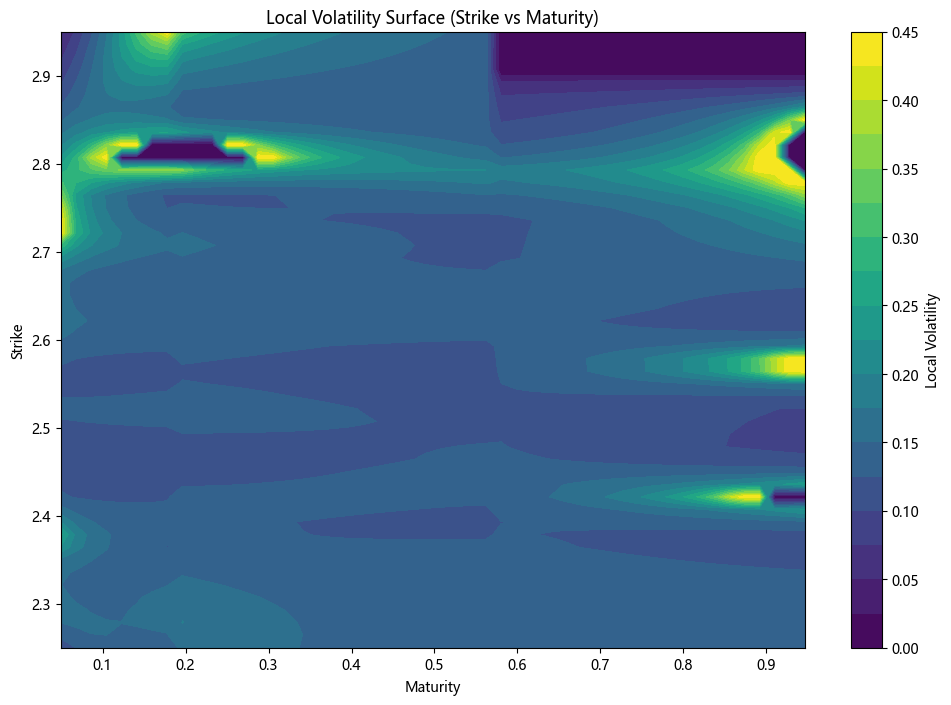

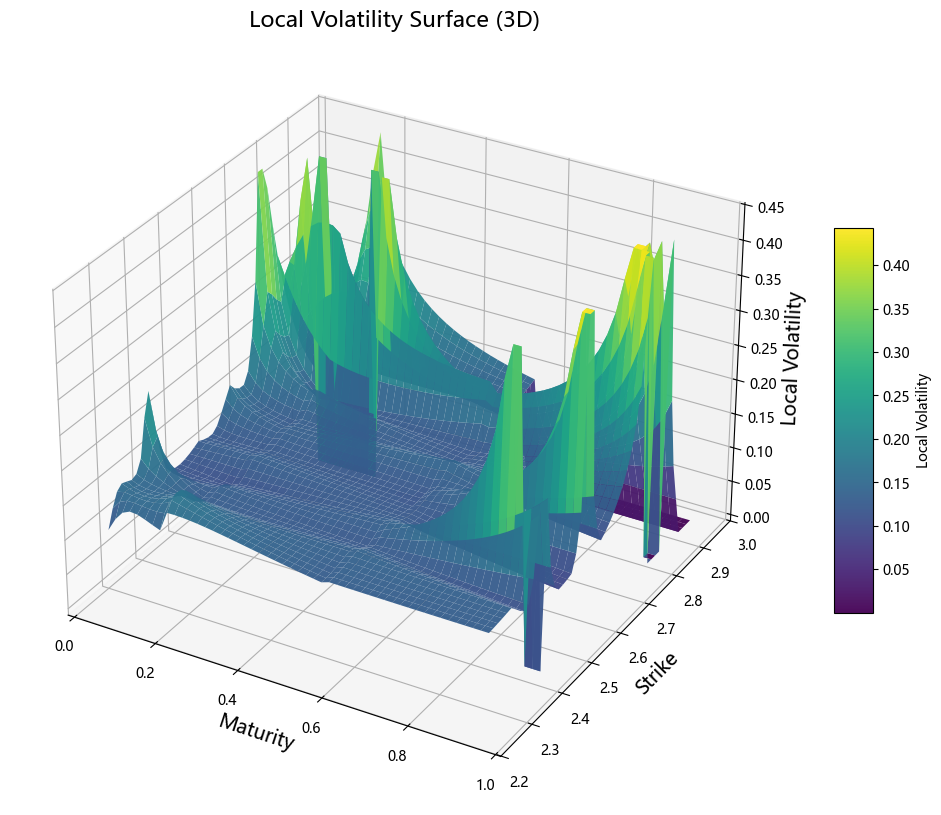

In [11]:
# 设置参数
n_training_paths = 1000  # 减少路径数以加快调试
n_time_steps = 30
time_step = 1 / 250
initial_price = 3.0
initial_state = (initial_price,)

print("生成局部波动率曲面可视化...")

strike_min, strike_max = option['exerciseprice'].min(), option['exerciseprice'].max()
maturity_min, maturity_max = option['maturity'].min(), option['maturity'].max()
strike_range = np.linspace(strike_min, strike_max, 50)
maturity_range = np.linspace(maturity_min, maturity_max, 50)
strike_grid, maturity_grid = np.meshgrid(strike_range, maturity_range, indexing='ij')

F = option['F'].mean()
y_grid = np.log(strike_grid / F)

vol_surface = np.zeros_like(strike_grid)
for i in range(strike_grid.shape[0]):
    for j in range(strike_grid.shape[1]):
        y = y_grid[i, j]
        t = maturity_grid[i, j]
        try:
            v = local_v(option, spline, y, t)
            if np.isnan(v) or np.isinf(v):
                v = np.nan
        except Exception:
            v = np.nan
        vol_surface[i, j] = v

vmin, vmax = np.percentile(vol_surface, [1, 99])
Z_plot = np.clip(vol_surface, vmin, vmax)

# 2D contourf
plt.figure(figsize=(12, 8))
contour = plt.contourf(
    maturity_range, strike_range, np.clip(vol_surface, vmin, vmax),
    levels=20, cmap='viridis', vmin=vmin, vmax=vmax
)
plt.colorbar(contour, label='Local Volatility')
plt.xlabel('Maturity')
plt.ylabel('Strike')
plt.title('Local Volatility Surface (Strike vs Maturity)')
plt.show()

# 3D surface
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    maturity_grid, strike_grid, Z_plot,
    cmap='viridis', edgecolor='none', alpha=0.95
)
ax.set_xlabel('Maturity', fontsize=14)
ax.set_ylabel('Strike', fontsize=14)
ax.set_zlabel('Local Volatility', fontsize=14)
ax.set_title('Local Volatility Surface (3D)', fontsize=16)
fig.colorbar(surf, shrink=0.5, aspect=10, label='Local Volatility')
plt.show()


In [ ]:
n_training_paths = 1000
n_time_steps = 30
time_step = 1 / 250
initial_price = 3.0
sigma = 0.15759525293122356  # 常数波动率
strike_price = 3.0
time_to_maturity = n_time_steps * time_step
feature_list = ["log_moneyness", "expiry_time", "volatility", "prev_hedge"]
transaction_cost = 0.001
training_epochs = 100

# 1. 生成 spot 和 time 的取值范围
spot_min, spot_max = 2.5, 3.5  # 根据你的实际标的价格区间调整
time_min, time_max = 0.01, n_time_steps * time_step
spot_range = np.linspace(spot_min, spot_max, 100)
time_range = np.linspace(time_min, time_max, 100)
spot_grid, time_grid = np.meshgrid(spot_range, time_range, indexing='ij')

F = float(option['F'].mean())
y_grid = np.log(spot_grid / F)

# 2. 生成局部波动率查找表
vol_table = np.zeros_like(spot_grid)
for i in range(spot_grid.shape[0]):
    for j in range(spot_grid.shape[1]):
        y = y_grid[i, j]
        t = time_grid[i, j]
        try:
            v = local_v(option, spline, y, t)
            if np.isnan(v) or np.isinf(v):
                v = 0.0
        except Exception:
            v = 0.0
        vol_table[i, j] = v

# 3. 创建高效插值器
vol_interp = RegularGridInterpolator(
    (spot_range, time_range), vol_table, bounds_error=False, fill_value=0.0
)

# 4. robust sigma_fn，支持 tensor 批量输入
def sigma_fn(time, spot):
    # 转为 numpy
    spot_np = spot.detach().cpu().numpy() if isinstance(spot, torch.Tensor) else np.array(spot)
    time_np = time.detach().cpu().numpy() if isinstance(time, torch.Tensor) else np.array(time)
    # 广播到相同 shape
    spot_b, time_b = np.broadcast_arrays(spot_np, time_np)
    pts = np.stack([spot_b.ravel(), time_b.ravel()], axis=-1)
    v = vol_interp(pts)
    v = v.reshape(spot_b.shape)
    v_tensor = torch.from_numpy(v).to(time.device if isinstance(time, torch.Tensor) else 'cpu').type_as(time if isinstance(time, torch.Tensor) else torch.tensor(1.0))
    return v_tensor

# 5. 构造 LocalVolatilityStock
temp_lv_stock = LocalVolatilityStock(
    sigma_fn,
    transaction_cost,
    time_step
)
temp_option1 = EuropeanOption(temp_lv_stock, strike=strike_price, maturity=time_to_maturity)

temp_gbm_stock = BrownianStock(transaction_cost, time_step, sigma)
temp_option2 = EuropeanOption(temp_gbm_stock, strike=strike_price, maturity=time_to_maturity)

# 6. 风险度量
risk_measures = {
    "Entropic Risk (a=1.0)": EntropicRiskMeasure(a=1.0),
    "Entropic Risk (a=0.1)": EntropicRiskMeasure(a=0.1),
    "Expected Shortfall (95%)": ExpectedShortfall(0.05),
    "Expected Shortfall (50%)": ExpectedShortfall(0.5),
}

# 7. 训练对冲器
print("\n开始训练对冲器（使用局部波动率数据）...")
trained_hedgers = {}

# Black-Scholes（用于对比）
bs_hedger1 = BlackScholes(temp_option1)
trained_hedgers["BS1"] = {
    "model": bs_hedger1,
    "type": "black_scholes",
    "features": None
}

bs_hedger2 = BlackScholes(temp_option2)
trained_hedgers["BS2"] = {
    "model": bs_hedger2,
    "type": "black_scholes",
    "features": None
}


for risk_name, risk_measure in risk_measures.items():
    print(f"\n用Local Volatility训练 {risk_name}...")
    nn_hedger = create_lv_hedger(
        risk_measure,
        temp_option1,
        feature_list,
        training_epochs,
        n_training_paths,
        initial_price,
        sigma_fn,
    )
    trained_hedgers["LV + "+risk_name] = {
        "model": nn_hedger,
        "type": "neural_network", 
        "features": feature_list
    }

print("\n开始训练对冲器（使用几何布朗运动数据）...")
for risk_name, risk_measure in risk_measures.items():
    print(f"\n用Brownian Motion训练 {risk_name}...")
    nn_hedger = create_gbm_hedger(
        risk_measure,
        temp_option2,
        feature_list,
        training_epochs,
        n_training_paths,
        initial_price,
        sigma
    )
    trained_hedgers["GBM + "+risk_name] = {
        "model": nn_hedger,
        "type": "neural_network", 
        "features": feature_list
    }


开始训练对冲器（使用局部波动率数据）...

用Local Volatility训练 Entropic Risk (a=1.0)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.030583
  Epoch 40/100, Loss: 0.030951
  Epoch 60/100, Loss: 0.029408
  Epoch 80/100, Loss: 0.030713
  Epoch 100/100, Loss: 0.029968

用Local Volatility训练 Entropic Risk (a=0.1)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.029864
  Epoch 40/100, Loss: 0.029268
  Epoch 60/100, Loss: 0.029821
  Epoch 80/100, Loss: 0.029788
  Epoch 100/100, Loss: 0.030742

用Local Volatility训练 Expected Shortfall (95%)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.081864
  Epoch 40/100, Loss: 0.075699
  Epoch 60/100, Loss: 0.075809
  Epoch 80/100, Loss: 0.068454
  Epoch 100/100, Loss: 0.065763

用Local Volatility训练 Expected Shortfall (50%)...
  开始训练，总共 100 个 epochs...
  Epoch 20/100, Loss: 0.069657
  Epoch 40/100, Loss: 0.073910
  Epoch 60/100, Loss: 0.063871
  Epoch 80/100, Loss: 0.067027
  Epoch 100/100, Loss: 0.067845

开始训练对冲器（使用几何布朗运动数据）...

用Brownian Motion训练 Entropic Risk (

In [15]:
# 评估性能
print("\n评估对冲器性能（使用SSE50历史数据）...")

# 读取历史数据
hist_data = pd.read_csv(r"c:/Users/jimmy/Documents/workspace1/pfhedge-ty/examples/SSE50_Historical_Data.csv")
price_path = hist_data["close"].values  # shape: (n_steps,)

# 参数设置
strike_price = 1000  # 行权价，可以根据实际需要调整
time_to_maturity = len(price_path) - 1  # 到期天数
initial_price = price_path[0]
dt = 1/252  # 日度时间步长

# 滑动窗口参数
window_length = 252  # 一年交易日数
step_size = 1        # 每天滑动一步

print(f"历史数据长度: {len(price_path)} 天")
print(f"初始价格: {initial_price:.2f}")
print(f"最终价格: {price_path[-1]:.2f}")
print(f"行权价: {strike_price:.2f}")

# 滑动窗口回测
all_pnls = {hedger_name: [] for hedger_name in trained_hedgers.keys()}

# 遍历每个滑动窗口
for start_idx in range(0, len(price_path) - window_length, step_size):
    end_idx = start_idx + window_length
    window_prices = price_path[start_idx:end_idx]
    
    # 计算总窗口数
    total_windows = (len(price_path) - window_length) // step_size + 1
    current_window = start_idx//step_size + 1

    # 显示进度条
    progress = current_window / total_windows
    bar_length = 50
    filled_length = int(bar_length * progress)
    bar = '█' * filled_length + '-' * (bar_length - filled_length)
    print(f'\r进度: [{bar}] {current_window}/{total_windows} ({progress:.1%})', end='', flush=True)

# 在最后一个窗口完成后换行
    if current_window == total_windows:
        print()
    
    for hedger_name, hedger_data in trained_hedgers.items():
        # 计算对冲比率（使用window_prices替代price_path）
        if hedger_data.get("type") == "black_scholes":
            hedge_ratio = []
            for t in range(len(window_prices) - 1):
                spot = float(window_prices[t])
                maturity = float((len(window_prices) - 1 - t) * dt)
                vol = 0.2
                
                log_moneyness = np.log(spot / strike_price)
                delta = hedger_data["model"].delta(
                    log_moneyness=torch.tensor(log_moneyness, dtype=torch.float32),
                    time_to_maturity=torch.tensor(maturity, dtype=torch.float32),
                    volatility=torch.tensor(vol, dtype=torch.float32)
                )
                
                if isinstance(delta, torch.Tensor):
                    delta = delta.item()
                hedge_ratio.append(delta)
            hedge_ratio = np.array(hedge_ratio)
            
        else:
            # 神经网络模型部分保持不变，但使用window_prices
            hedge_ratio = []
            current_hedge = 0.0
            
            for t in range(len(window_prices) - 1):
                spot = float(window_prices[t])
                maturity = float((len(window_prices) - 1 - t) * dt)
                
                log_moneyness = np.log(spot / strike_price)
                expiry_time = maturity
                volatility = 0.2
                prev_hedge = current_hedge
                
                features = torch.tensor([
                    [log_moneyness, expiry_time, volatility, prev_hedge]
                ], dtype=torch.float32)
                
                with torch.no_grad():
                    new_hedge = hedger_data["model"](features)
                    new_hedge = new_hedge.cpu().numpy().flatten()[0]
                
                hedge_ratio.append(new_hedge)
                current_hedge = new_hedge
            
            hedge_ratio = np.array(hedge_ratio)

        # 计算对冲损益（使用window_prices）
        cash = 0.0
        position = 0.0
        transaction_cost = 0.001
        
        for t in range(len(window_prices) - 1):
            delta_pos = hedge_ratio[t] - position
            
            if abs(delta_pos) > 0:
                cash -= abs(delta_pos) * window_prices[t+1] * transaction_cost
            
            cash -= delta_pos * window_prices[t+1]
            position = hedge_ratio[t]
            
            if t == len(window_prices) - 2:
                cash += position * window_prices[-1]
        
        option_payoff = max(window_prices[-1] - strike_price, 0)
        pnl = cash + option_payoff
        all_pnls[hedger_name].append(pnl)

# 计算统计结果
performance_results = {}
for hedger_name, pnls in all_pnls.items():
    mean_pnl = np.mean(pnls)
    std_pnl = np.std(pnls)
    performance_results[hedger_name] = {
        'mean_pnl': mean_pnl,
        'std_pnl': std_pnl,
        'all_pnls': pnls
    }
    print(f"{hedger_name} 平均PnL: {mean_pnl:.6f}, 标准差: {std_pnl:.6f}")


评估对冲器性能（使用SSE50历史数据）...
历史数据长度: 5236 天
初始价格: 1011.35
最终价格: 2812.44
行权价: 1000.00
进度: [--------------------------------------------------] 1/4985 (0.0%)

进度: [█████████████████████████████████████████████████-] 4984/4985 (100.0%)Black-Scholes1 平均PnL: 1390.220962, 标准差: 1336.379658
Black-Scholes2 平均PnL: 1390.220962, 标准差: 1336.379658
Local Volatility + Entropic Risk (a=1.0) 平均PnL: 1355.249363, 标准差: 970.411506
Local Volatility + Entropic Risk (a=0.1) 平均PnL: 1327.791803, 标准差: 763.414090
Local Volatility + Expected Shortfall (95%) 平均PnL: 1351.996041, 标准差: 1055.225992
Local Volatility + Expected Shortfall (50%) 平均PnL: 1308.424538, 标准差: 666.081406
Brownian Motion + Entropic Risk (a=1.0) 平均PnL: 1352.978870, 标准差: 1052.581337
Brownian Motion + Entropic Risk (a=0.1) 平均PnL: 1341.564427, 标准差: 855.040937
Brownian Motion + Expected Shortfall (95%) 平均PnL: 1360.255290, 标准差: 1130.146386
Brownian Motion + Expected Shortfall (50%) 平均PnL: 1359.735483, 标准差: 1144.985896


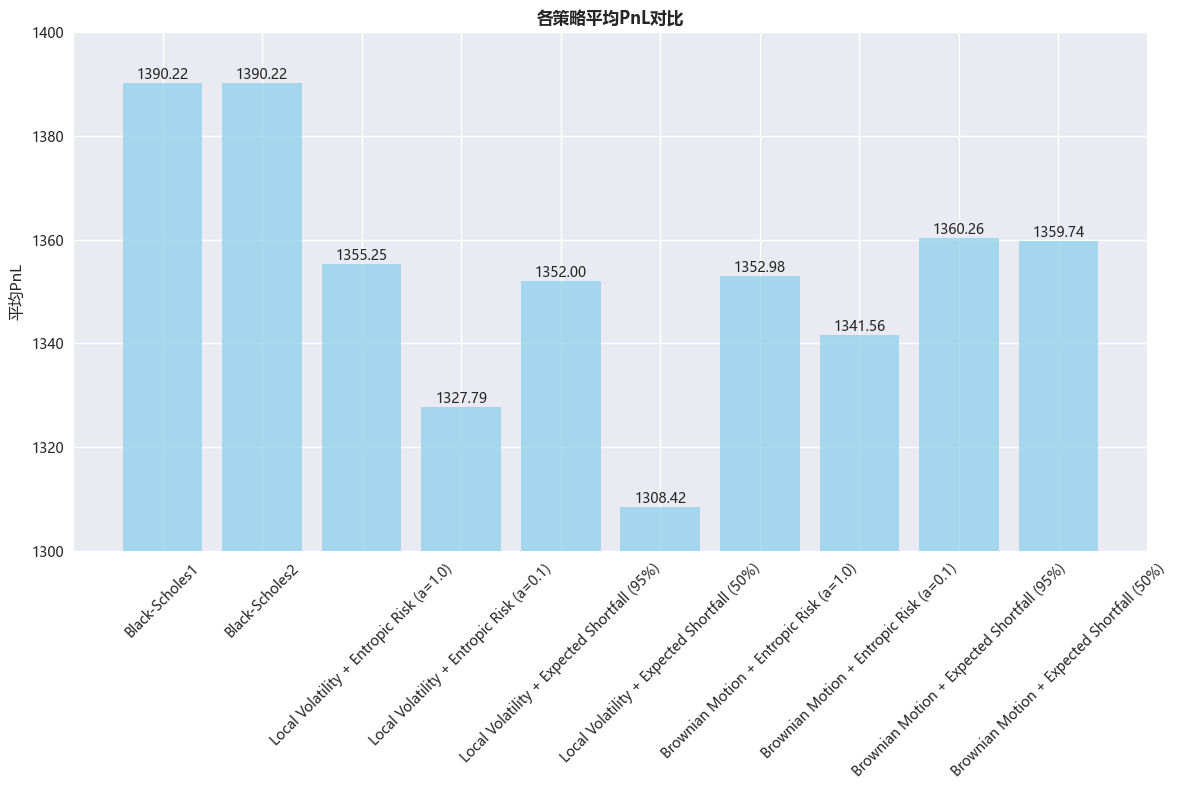

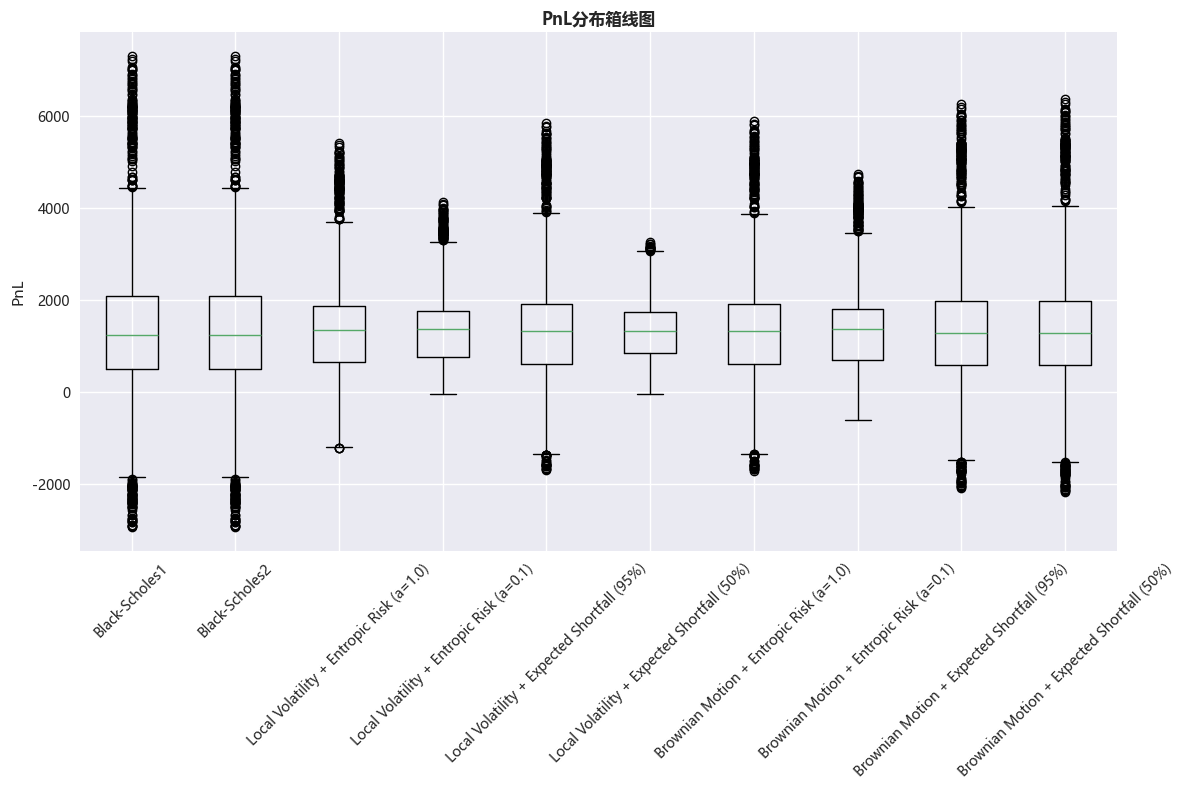

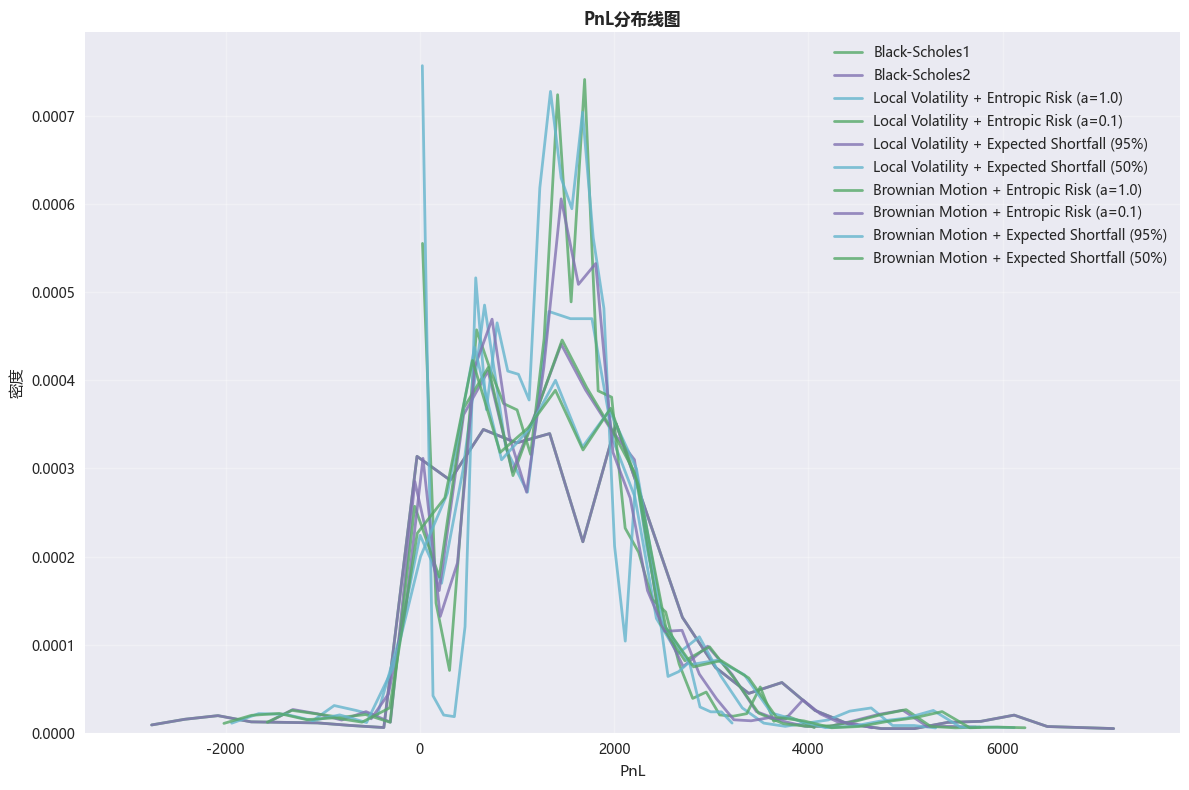

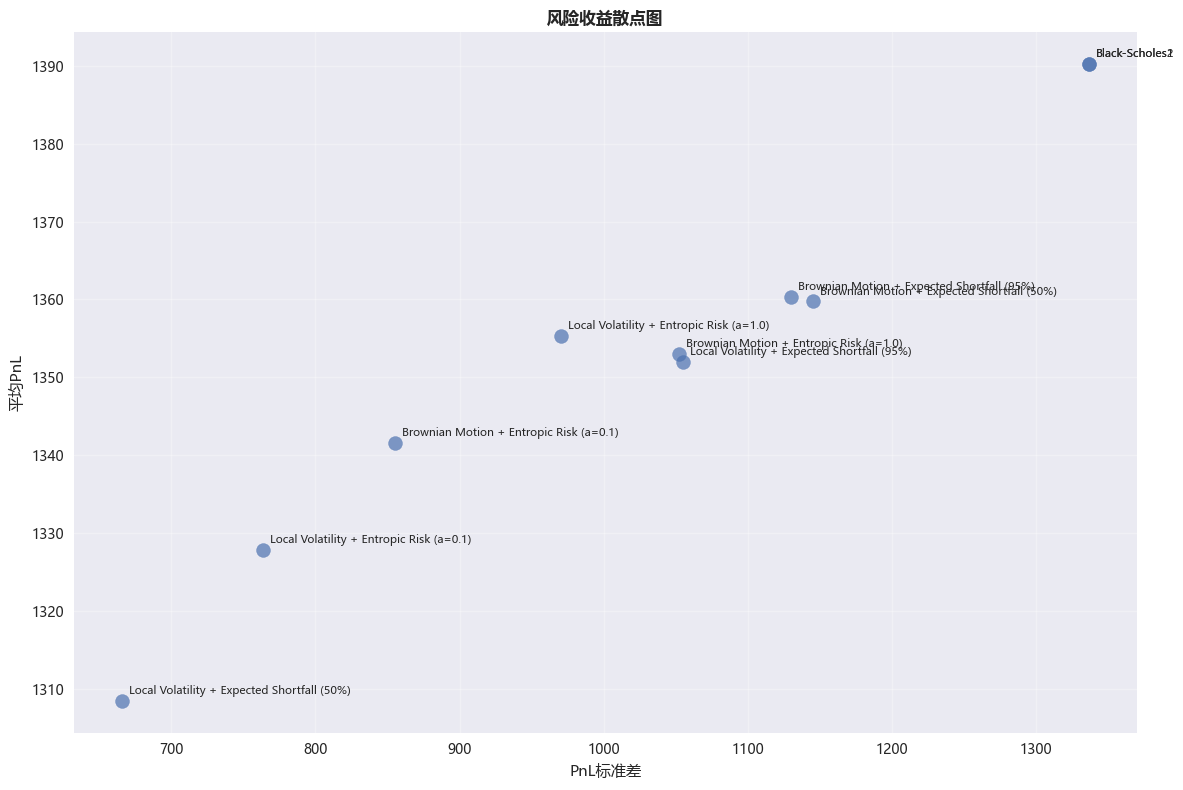


详细统计信息
策略名称                           | 平均PnL        | 标准差          | 最小值          | 最大值         
--------------------------------------------------------------------------------
Black-Scholes1                 | 1390.220962  | 1336.379658  | -2931.493329 | 7314.362035 
Black-Scholes2                 | 1390.220962  | 1336.379658  | -2931.493329 | 7314.362035 
Local Volatility + Entropic Risk (a=1.0) | 1355.249363  | 970.411506   | -1212.968101 | 5421.138891 
Local Volatility + Entropic Risk (a=0.1) | 1327.791803  | 763.414090   | -41.294808   | 4131.011355 
Local Volatility + Expected Shortfall (95%) | 1351.996041  | 1055.225992  | -1683.614263 | 5852.037152 
Local Volatility + Expected Shortfall (50%) | 1308.424538  | 666.081406   | -28.851504   | 3270.236304 
Brownian Motion + Entropic Risk (a=1.0) | 1352.978870  | 1052.581337  | -1696.597083 | 5892.188989 
Brownian Motion + Entropic Risk (a=0.1) | 1341.564427  | 855.040937   | -589.349517  | 4744.866069 
Brownian Motion + Expected S

In [25]:
# 可视化结果
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 10  # 设置默认字体大小

# 图1：平均PnL对比
plt.figure(figsize=(12, 8))
strategies = list(performance_results.keys())
mean_pnls = [performance_results[s]['mean_pnl'] for s in strategies]

bars = plt.bar(strategies, mean_pnls, color='skyblue', alpha=0.7)
plt.title('各策略平均PnL对比', fontsize=12, fontweight='bold')
plt.ylabel('平均PnL')
plt.xticks(rotation=45)

# 设置纵坐标范围
plt.ylim(1300, 1400)

# 在柱状图上添加数值标签
for bar, pnl in zip(bars, mean_pnls):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{pnl:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 图2：PnL分布箱线图
plt.figure(figsize=(12, 8))
pnl_data = [performance_results[s]['all_pnls'] for s in strategies]
plt.boxplot(pnl_data, tick_labels=strategies)
plt.title('PnL分布箱线图', fontsize=12, fontweight='bold')
plt.ylabel('PnL')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 图3：PnL分布线图
plt.figure(figsize=(12, 8))
for i, strategy in enumerate(strategies):
    # 计算直方图数据但不绘制
    counts, bins, _ = plt.hist(performance_results[strategy]['all_pnls'], 
                               bins=30, alpha=0, density=True)
    # 计算bin中心点
    bin_centers = (bins[:-1] + bins[1:]) / 2
    # 绘制线图
    plt.plot(bin_centers, counts, label=strategy, linewidth=2, alpha=0.8)
plt.title('PnL分布线图', fontsize=12, fontweight='bold')
plt.xlabel('PnL')
plt.ylabel('密度')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 图4：风险收益散点图
plt.figure(figsize=(12, 8))
means = [performance_results[s]['mean_pnl'] for s in strategies]
stds = [performance_results[s]['std_pnl'] for s in strategies]

scatter = plt.scatter(stds, means, s=100, alpha=0.7)
plt.xlabel('PnL标准差')
plt.ylabel('平均PnL')
plt.title('风险收益散点图', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 添加策略标签
for i, strategy in enumerate(strategies):
    plt.annotate(strategy, (stds[i], means[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

# 打印详细统计信息
print("\n" + "="*80)
print("详细统计信息")
print("="*80)
print(f"{'策略名称':<30} | {'平均PnL':<12} | {'标准差':<12} | {'最小值':<12} | {'最大值':<12}")
print("-"*80)

for strategy in strategies:
    pnls = performance_results[strategy]['all_pnls']
    mean_pnl = performance_results[strategy]['mean_pnl']
    std_pnl = performance_results[strategy]['std_pnl']
    min_pnl = np.min(pnls)
    max_pnl = np.max(pnls)
    
    print(f"{strategy:<30} | {mean_pnl:<12.6f} | {std_pnl:<12.6f} | {min_pnl:<12.6f} | {max_pnl:<12.6f}")

print("="*80)